In [ ]:
'''
Hi, reader.
Ok I've lowk realised i need to get better at data preprocessing and cleaning,
so this is a subquest in my ML journey, bc we lowk need to build actual pipelines as
data wouldnt be so clean.

Ok here are the steps i've learnt to take, in order to build a ML-optimal pipeline
[1] Import libs
[2] Read dataset
[3] Sanity check
[4] EDA
[5] Missing values 
[6] Outliers
[7] Duplicates and garbage values
[8] Normalization and Encoding
'''
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#load data
data = pd.read_csv("Life Expectancy Data.csv")
#sanity check
print(data.shape) #2938 rows, 22 columns(features)
print(f"Number of missing values: {data.isnull().sum().sum()}") #sums all the missing values per column
print(f"Percetage of missing values: {(data.isnull().sum() / data.shape[0]) * 100}")
print(f"Number of duplicates: {data.duplicated().sum()}")
#detects garbage values
for i in data.select_dtypes(include='object').columns:
    print(data[i].value_counts())
    print('***'*10)

#EDA
print(data.describe().T) #provides descriptive stats

(2938, 22)
Number of missing values: 2563
Percetage of missing values: Country                             0.000000
Year                                0.000000
Status                              0.000000
Life expectancy                     0.340368
Adult Mortality                     0.340368
infant deaths                       0.000000
Alcohol                             6.603131
percentage expenditure              0.000000
Hepatitis B                        18.822328
Measles                             0.000000
 BMI                                1.157250
under-five deaths                   0.000000
Polio                               0.646698
Total expenditure                   7.692308
Diphtheria                          0.646698
 HIV/AIDS                           0.000000
GDP                                15.248468
Population                         22.191967
 thinness  1-19 years               1.157250
 thinness 5-9 years                 1.157250
Income composition of resourc

Columns w missing values: []
Country                            0
Year                               0
Status                             0
Life expectancy                    0
Adult Mortality                    0
infant deaths                      0
Alcohol                            0
percentage expenditure             0
Hepatitis B                        0
Measles                            0
 BMI                               0
under-five deaths                  0
Polio                              0
Total expenditure                  0
Diphtheria                         0
 HIV/AIDS                          0
GDP                                0
Population                         0
 thinness  1-19 years              0
 thinness 5-9 years                0
Income composition of resources    0
Schooling                          0
dtype: int64


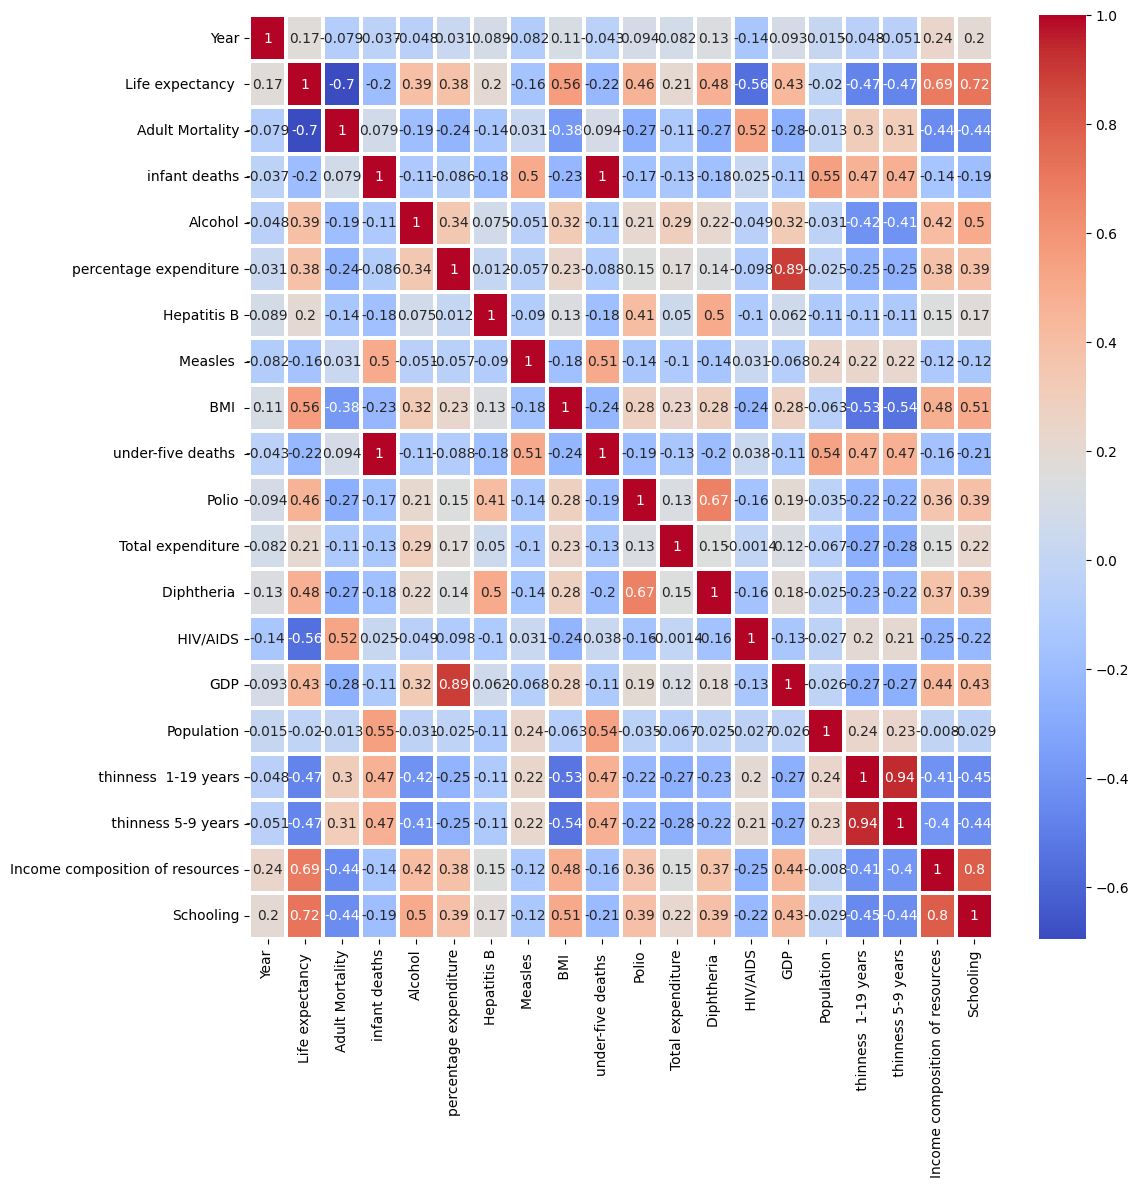

In [ ]:
#correlation matrix to show relationships, we try show relationships to alcohol
corr = data.corr('pearson', numeric_only=True)
plt.figure(figsize=(12, 12))
sns.heatmap(corr, cmap='coolwarm', linewidths=1.5, annot=True)
corr_alc = corr['Alcohol'].abs() #compute abs
best_features = corr_alc[corr_alc > 0.3].index.tolist()
best_features.remove('Alcohol') #removes target value

#OK missing values treatment: Mean, Median, KNNImputer: 
# KNN (K-Nearest Neighbors) Imputer is a machine learning method used to fill in missing values in a dataset by finding the most similar data points
from sklearn.impute import KNNImputer
imputer = KNNImputer()
missing_cols = data.columns[data.isnull().any()].tolist()
print("Columns w missing values:", missing_cols)
for i in data[missing_cols]:
    data[i] = imputer.fit_transform(data[[i]]) #imputes all missing values
    



In [56]:
#Ayt now on to outlier detection and treatment
#rem IQR = Q3 - Q1, 
#Outliers: Lower  < Q1 - 1.5(IQR), Upper > Q3 - 1.5(IQR)
def detect_outliers(col):
    q1, q3 = np.percentile(col, [25, 75])
    iqr = q3 - q1
    lw = q1 - 1.5*iqr
    up = q3 + 1.5*iqr
    return lw, up
for i in data.select_dtypes(include='number').columns:
    lw, up = detect_outliers(data[i])
    data[i] = np.where(data[i] > up, up, np.where(data[i] < lw, lw, data[i]))